In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df=pd.read_csv("/restaurants.csv")
df

,Restaurant_ID,Name,City,State,Country,Zip_Code,Latitude,Longitude,Alcohol_Service,Smoking_Allowed,Price,Franchise,Area,Parking
0,132560,Puesto de Gorditas,Ciudad Victoria,Tamaulipas,Mexico,NaN,23.752304,-99.166913,NaN,Yes,Low,No,Open,Public
1,132561,Cafe Ambar,Ciudad Victoria,Tamaulipas,Mexico,NaN,23.726819,-99.126506,NaN,No,Low,No,Closed,NaN
2,132564,Church's,Ciudad Victoria,Tamaulipas,Mexico,NaN,23.730925,-99.145185,NaN,No,Low,No,Closed,NaN
3,132572,Cafe Chaires,San Luis Potosi,San Luis Potosi,Mexico,NaN,22.141647,-100.992712,NaN,No,Low,No,Closed,Yes
4,132583,McDonalds Centro,Cuernavaca,Morelos,Mexico,62000.0,18.922290,-99.234332,NaN,No,Low,Yes,Closed,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,135088,Cafeteria Cenidet,Cuernavaca,Morelos,Mexico,NaN,18.876011,-99.219890,NaN,No,Low,No,Closed,Public
126,135104,Vips,Ciudad Victoria,Tamaulipas,Mexico,NaN,23.752982,-99.168434,Full Bar,No,Medium,Yes,Closed,Yes
127,135106,El Rincón De San Francisco,San Luis Potosi,San Luis Potosi,Mexico,78000.0,22.149709,-100.976093,Wine & Beer,Bar Only,Medium,No,Open,NaN
128,135108,Potzocalli,San Luis Potosi,San Luis Potosi,Mexico,NaN,22.136253,-100.933585,NaN,No,Low,No,Closed,NaN


In [18]:
print("First 5 rows: ")
print(df.head())

First 5 rows: 
   Restaurant_ID                Name             City  ... Franchise    Area  Parking
0         132560  Puesto de Gorditas  Ciudad Victoria  ...        No    Open   Public
1         132561          Cafe Ambar  Ciudad Victoria  ...        No  Closed      NaN
2         132564            Church's  Ciudad Victoria  ...        No  Closed      NaN
3         132572        Cafe Chaires  San Luis Potosi  ...        No  Closed      Yes
4         132583    McDonalds Centro       Cuernavaca  ...       Yes  Closed      NaN

[5 rows x 14 columns]


In [19]:
print("Last 5 rows: ")
print(df.tail())

Last 5 rows: 
     Restaurant_ID                        Name  ...    Area Parking
125         135088           Cafeteria Cenidet  ...  Closed  Public
126         135104                        Vips  ...  Closed     Yes
127         135106  El Rincón De San Francisco  ...    Open     NaN
128         135108                  Potzocalli  ...  Closed     NaN
129         135109                   Paniroles  ...  Closed     NaN

[5 rows x 14 columns]


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant_ID    130 non-null    int64  
 1   Name             130 non-null    object 
 2   City             130 non-null    object 
 3   State            130 non-null    object 
 4   Country          130 non-null    object 
 5   Zip_Code         56 non-null     float64
 6   Latitude         130 non-null    float64
 7   Longitude        130 non-null    float64
 8   Alcohol_Service  43 non-null     object 
 9   Smoking_Allowed  130 non-null    object 
 10  Price            130 non-null    object 
 11  Franchise        130 non-null    object 
 12  Area             130 non-null    object 
 13  Parking          65 non-null     object 
dtypes: float64(3), int64(1), object(10)
memory usage: 14.3+ KB
None


In [20]:
print(df.isnull().sum())

Restaurant_ID       0
Name                0
City                0
State               0
Country             0
Zip_Code           74
Latitude            0
Longitude           0
Alcohol_Service    87
Smoking_Allowed     0
Price               0
Franchise           0
Area                0
Parking            65
dtype: int64


In [21]:
print(df["City"].value_counts())

City
San Luis Potosi    84
Ciudad Victoria    23
Cuernavaca         21
Jiutepec            2
Name: count, dtype: int64


In [22]:
print(df["State"].value_counts())

State
San Luis Potosi    84
Tamaulipas         23
Morelos            23
Name: count, dtype: int64


In [23]:
print(df["Price"].value_counts())

Price
Medium    60
Low       45
High      25
Name: count, dtype: int64


In [26]:
print(df[df["Alcohol_Service"]!="None"])

     Restaurant_ID                        Name  ...    Area Parking
0           132560          Puesto de Gorditas  ...    Open  Public
1           132561                  Cafe Ambar  ...  Closed     NaN
2           132564                    Church's  ...  Closed     NaN
3           132572                Cafe Chaires  ...  Closed     Yes
4           132583            McDonalds Centro  ...  Closed     NaN
..             ...                         ...  ...     ...     ...
125         135088           Cafeteria Cenidet  ...  Closed  Public
126         135104                        Vips  ...  Closed     Yes
127         135106  El Rincón De San Francisco  ...    Open     NaN
128         135108                  Potzocalli  ...  Closed     NaN
129         135109                   Paniroles  ...  Closed     NaN

[130 rows x 14 columns]


In [30]:
franchise=df[df["Franchise"]=="Yes"]
print(franchise)

     Restaurant_ID                            Name  ...    Area Parking
4           132583                McDonalds Centro  ...  Closed     NaN
5           132584              Gorditas Doña Tota  ...  Closed     Yes
7           132608          Hamburguesas La Perica  ...    Open  Public
8           132609        Pollo Frito Buenos Aires  ...  Closed     Yes
9           132613                   Carnitas Mata  ...  Closed     Yes
10          132626           La Perica Hamburguesa  ...  Closed     Yes
16          132667  Little Pizza Emilio Portes Gil  ...  Closed     NaN
18          132706              Gorditas Dona Tota  ...  Closed  Public
23          132733                  Little Caesars  ...  Closed     Yes
29          132768              Mariscos Tia Licha  ...  Closed     NaN
41          132861                       Carl's Jr  ...  Closed     Yes
47          132875                       Shi Ro Ie  ...    Open   Valet
56          132954                    La Parroquia  ...  Closed 

In [31]:
franchise=df[df["Franchise"]=="No"]
print(franchise)

     Restaurant_ID                                Name  ...    Area Parking
0           132560                  Puesto de Gorditas  ...    Open  Public
1           132561                          Cafe Ambar  ...  Closed     NaN
2           132564                            Church's  ...  Closed     NaN
3           132572                        Cafe Chaires  ...  Closed     Yes
6           132594  Tacos De Barbacoa Enfrente Del Tec  ...    Open  Public
..             ...                                 ...  ...     ...     ...
123         135085              Tortas Locas Hipocampo  ...  Closed  Public
125         135088                   Cafeteria Cenidet  ...  Closed  Public
127         135106          El Rincón De San Francisco  ...    Open     NaN
128         135108                          Potzocalli  ...  Closed     NaN
129         135109                           Paniroles  ...  Closed     NaN

[108 rows x 14 columns]


In [33]:
print(df[df["Smoking_Allowed"]!="No"])

     Restaurant_ID  ... Parking
0           132560  ...  Public
7           132608  ...  Public
9           132613  ...     Yes
21          132723  ...  Public
24          132740  ...     NaN
28          132767  ...     Yes
30          132773  ...     NaN
35          132846  ...     NaN
47          132875  ...   Valet
51          132921  ...     NaN
52          132922  ...     NaN
54          132937  ...     NaN
59          134975  ...   Valet
61          134983  ...     Yes
64          134992  ...     Yes
65          134996  ...     Yes
72          135018  ...     Yes
80          135032  ...  Public
81          135033  ...     NaN
83          135035  ...     Yes
84          135038  ...     NaN
85          135039  ...     Yes
93          135047  ...     Yes
97          135051  ...     NaN
99          135053  ...     Yes
101         135055  ...     Yes
102         135057  ...     Yes
104         135059  ...     Yes
109         135065  ...     NaN
110         135066  ...     Yes
113     

In [34]:
print(df["Parking"].value_counts(dropna=False))

Parking
NaN       65
Yes       46
Public    16
Valet      3
Name: count, dtype: int64


In [36]:
city=input("Enter city name: ")
print(df[df["City"]==city])

Enter city name: Carnitas Mata Calle
Empty DataFrame
Columns: [Restaurant_ID, Name, City, State, Country, Zip_Code, Latitude, Longitude, Alcohol_Service, Smoking_Allowed, Price, Franchise, Area, Parking]
Index: []


In [37]:
print(df.sort_values("Name"))

     Restaurant_ID                            Name  ...    Area Parking
111         135069       Abondance Restaurante Bar  ...  Closed     Yes
71          135016                 Arrachela Grill  ...  Closed     NaN
25          132754                 Cabana Huasteca  ...  Closed     NaN
1           132561                      Cafe Ambar  ...  Closed     NaN
3           132572                    Cafe Chaires  ...  Closed     Yes
..             ...                             ...  ...     ...     ...
45          132870  Tortas Y Hamburguesas El Gordo  ...  Closed     NaN
39          132856                  Unicol's Pizza  ...  Closed     NaN
55          132951                            Vips  ...  Closed     Yes
68          135001                            Vips  ...  Closed     Yes
126         135104                            Vips  ...  Closed     Yes

[130 rows x 14 columns]


In [38]:
print(df.sort_values("City"))

     Restaurant_ID                                Name  ...    Area Parking
0           132560                  Puesto de Gorditas  ...    Open  Public
24          132740       Carreton De Flautas Y Migadas  ...    Open     NaN
23          132733                      Little Caesars  ...  Closed     Yes
22          132732                  Taqueria El Amigo   ...    Open     NaN
20          132717                       Tortas Hawaii  ...  Closed  Public
..             ...                                 ...  ...     ...     ...
128         135108                          Potzocalli  ...  Closed     NaN
33          132834                 Gorditas Doa Gloria  ...  Closed  Public
34          132845  Cenaduria El Rincón De Tlaquepaque  ...  Closed     NaN
75          135025          El Rincon De San Francisco  ...  Closed     NaN
84          135038               Restaurant La Chalita  ...  Closed     NaN

[130 rows x 14 columns]


In [39]:
print(df["Area"].value_counts())

Area
Closed    115
Open       15
Name: count, dtype: int64


In [40]:
print(df["City"].unique())

['Ciudad Victoria' 'San Luis Potosi' 'Cuernavaca' 'Jiutepec']


In [41]:
print(df["City"].nunique())

4


In [42]:
group = df.groupby("State").size()
print(group)

State
Morelos            23
San Luis Potosi    84
Tamaulipas         23
dtype: int64


In [43]:
clean = df.dropna()
clean.to_csv("clean_restaurants.csv", index=False)
print("Clean dataset saved.")

Clean dataset saved.


In [44]:
print(df[df.duplicated()])

Empty DataFrame
Columns: [Restaurant_ID, Name, City, State, Country, Zip_Code, Latitude, Longitude, Alcohol_Service, Smoking_Allowed, Price, Franchise, Area, Parking]
Index: []


In [45]:
print("Rows and Columns:", df.shape)

Rows and Columns: (130, 14)


In [46]:
print(df.columns)

Index(['Restaurant_ID', 'Name', 'City', 'State', 'Country', 'Zip_Code',
       'Latitude', 'Longitude', 'Alcohol_Service', 'Smoking_Allowed', 'Price',
       'Franchise', 'Area', 'Parking'],
      dtype='object')


In [47]:
print(df[df["Parking"] == "Public"])

     Restaurant_ID                                Name  ...    Area Parking
0           132560                  Puesto de Gorditas  ...    Open  Public
6           132594  Tacos De Barbacoa Enfrente Del Tec  ...    Open  Public
7           132608              Hamburguesas La Perica  ...    Open  Public
18          132706                  Gorditas Dona Tota  ...  Closed  Public
20          132717                       Tortas Hawaii  ...  Closed  Public
21          132723                   Gordas De Morales  ...  Closed  Public
26          132755                La Estrella De Dimas  ...  Closed  Public
33          132834                 Gorditas Doa Gloria  ...  Closed  Public
46          132872                     Pizzeria Julios  ...  Closed  Public
50          132885                   Hamburguesas Saul  ...  Closed  Public
74          135021                              Subway  ...  Closed  Public
80          135032  Cafeteria Y Restaurant El Pacifico  ...  Closed  Public
103         

In [48]:
print(df["Country"].value_counts())

Country
Mexico    130
Name: count, dtype: int64


In [49]:
print("Total restaurants:", len(df))

Total restaurants: 130


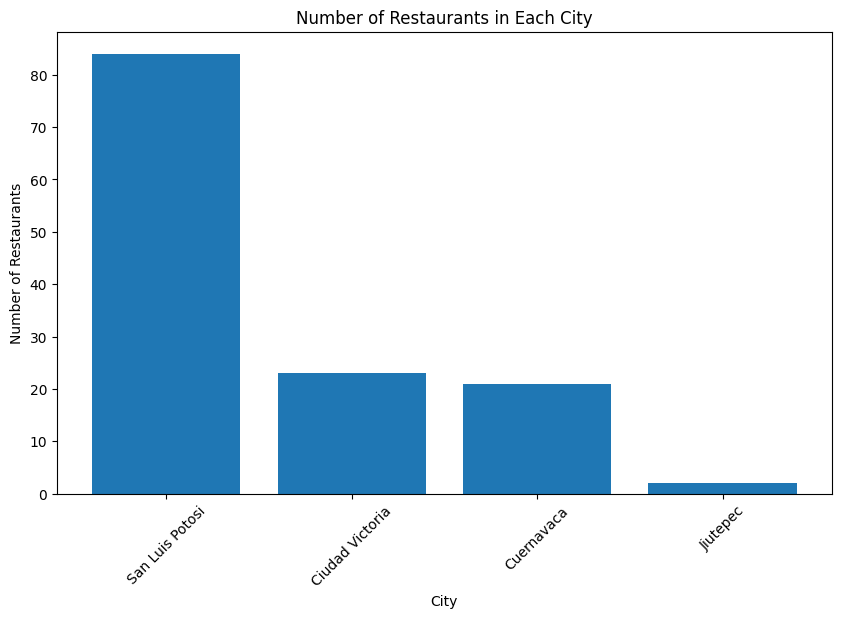

In [53]:
city = df["City"].value_counts()

plt.figure(figsize=(10,6))
plt.bar(city.index, city.values)
plt.title("Number of Restaurants in Each City")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

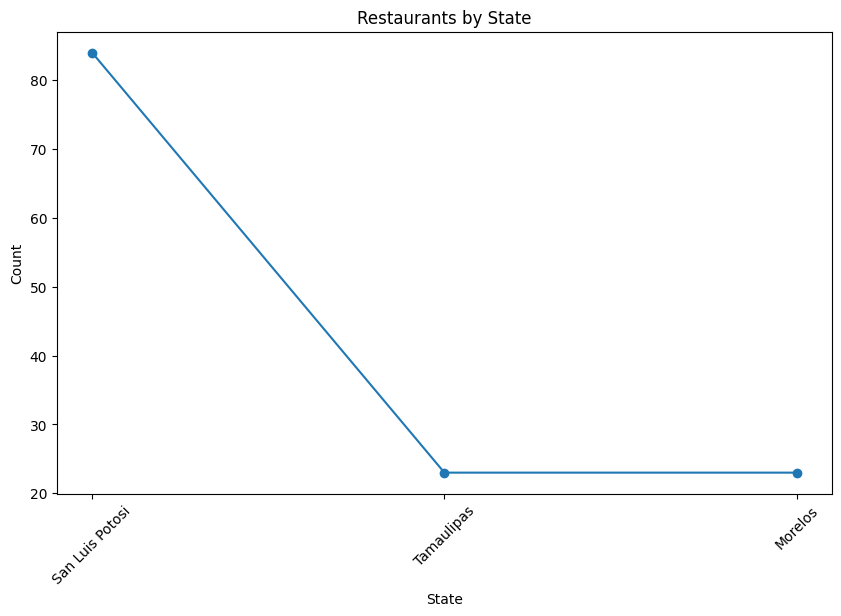

In [54]:
state = df["State"].value_counts()
plt.figure(figsize=(10,6))
plt.plot(state.index, state.values, marker='o')
plt.title("Restaurants by State")
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

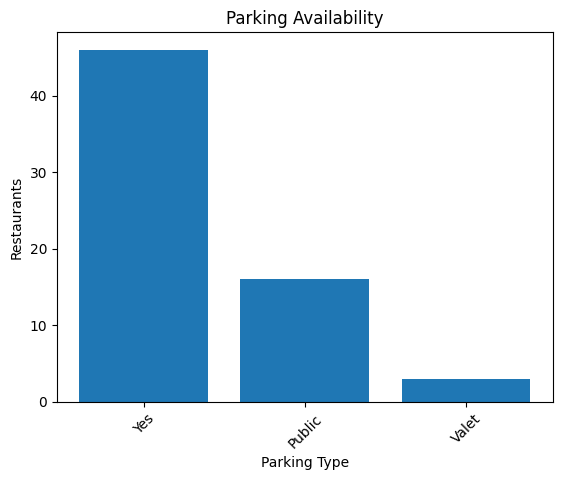

In [55]:
parking = df["Parking"].value_counts()
plt.bar(parking.index, parking.values)
plt.title("Parking Availability")
plt.xlabel("Parking Type")
plt.ylabel("Restaurants")
plt.xticks(rotation=45)
plt.show()